# Notebook 02 — Digital Down-Conversion & Signal Processing

**Project 2 — Superconducting Qubit Readout Signal Processing Pipeline**

---

## Theory

The heterodyne detection chain converts the cavity output to a digital baseband I/Q signal through five stages:

| Stage | Operation | Purpose |
|:---:|:---|:---|
| 1 | IF upconversion | Simulate heterodyne: $s_{\rm rf}(t) = \mathrm{Re}[\alpha(t)\,e^{j\omega_{\rm IF}t}]$ |
| 2 | DDC mixing | Multiply by $e^{-j\omega_{\rm IF}t}$ → complex baseband |
| 3 | FIR LPF | Remove image at $-2f_{\rm IF}$; 63-tap Hamming-windowed sinc |
| 4 | Decimation | Downsample by 8 (after LPF to prevent aliasing) |
| 5 | Integration | Box-car or matched filter → single I/Q point per shot |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from src.transmon import simulate_shots
from src.readout_chain import (
    process_shots_batch, process_single_shot,
    DEFAULT_CHAIN, build_lpf)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

data    = simulate_shots(n_shots=200, rng_seed=0)
t       = data["t"]
shots_0 = data["shots_0"]
shots_1 = data["shots_1"]
alpha_0 = data["alpha_0"]
alpha_1 = data["alpha_1"]
template = alpha_0 - alpha_1

## 2.1 FIR filter frequency response

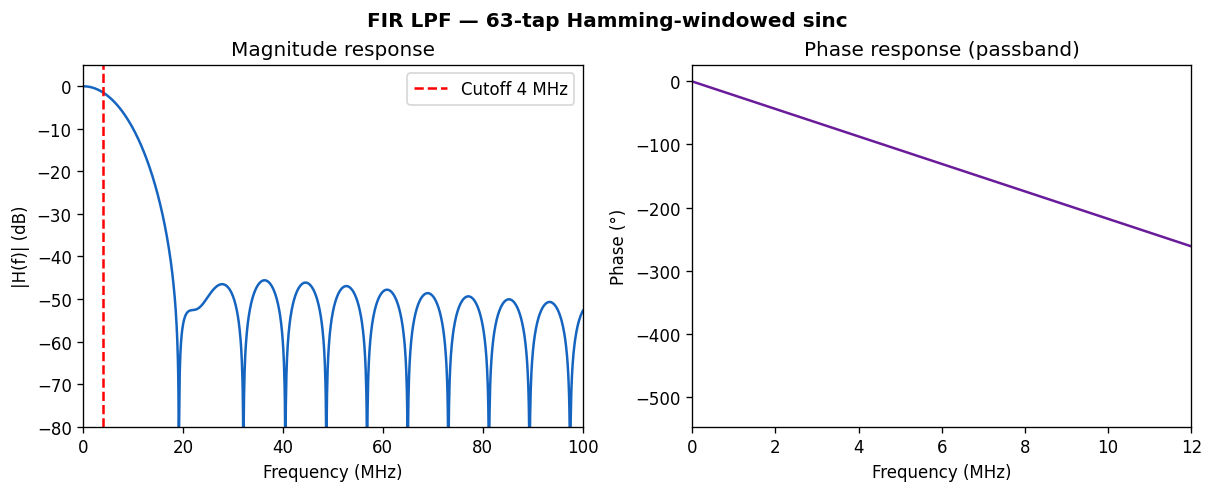

In [2]:
from scipy.signal import freqz

h    = build_lpf(DEFAULT_CHAIN)
w, H = freqz(h, worN=4096, fs=DEFAULT_CHAIN.fs)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
fig.suptitle(f"FIR LPF — {DEFAULT_CHAIN.fir_taps}-tap Hamming-windowed sinc", fontweight="bold")

axes[0].plot(w/1e6, 20*np.log10(np.abs(H)+1e-12), "#1565C0")
axes[0].axvline(DEFAULT_CHAIN.fir_cutoff/1e6, color="red", linestyle="--",
                label=f"Cutoff {DEFAULT_CHAIN.fir_cutoff/1e6:.0f} MHz")
axes[0].set_xlim([0, 100]); axes[0].set_ylim([-80, 5])
axes[0].set_xlabel("Frequency (MHz)"); axes[0].set_ylabel("|H(f)| (dB)")
axes[0].set_title("Magnitude response"); axes[0].legend()

axes[1].plot(w/1e6, np.unwrap(np.angle(H, deg=False))*180/np.pi, "#6A1B9A")
axes[1].set_xlim([0, DEFAULT_CHAIN.fir_cutoff/1e6*3])
axes[1].set_xlabel("Frequency (MHz)"); axes[1].set_ylabel("Phase (°)")
axes[1].set_title("Phase response (passband)")
plt.show()

## 2.2 Processing pipeline — single shot waterfall

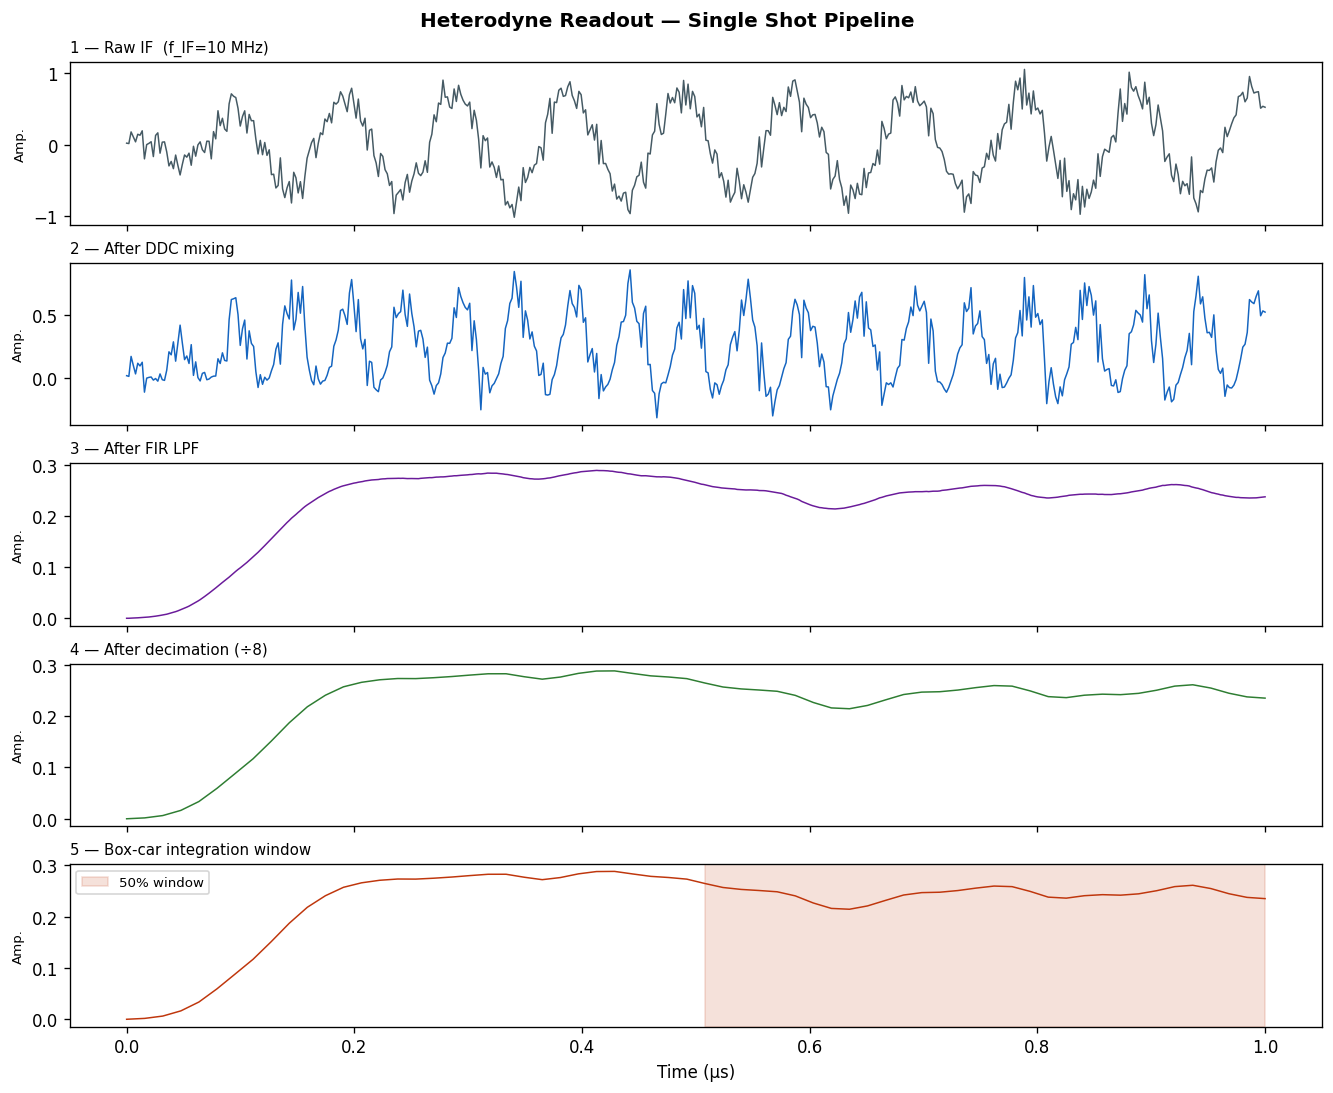

In [3]:
import matplotlib.gridspec as gridspec

shot_res = process_single_shot(shots_0[0], t)
t_us     = t * 1e6
n_dec    = shot_res["after_dec"].shape[0]
t_dec_us = np.linspace(0, t[-1]*1e6, n_dec)

fig = plt.figure(figsize=(11, 9), constrained_layout=True)
fig.suptitle("Heterodyne Readout — Single Shot Pipeline",
             fontsize=12, fontweight="bold")
gs   = gridspec.GridSpec(5, 1, figure=fig)
axs  = [fig.add_subplot(gs[i]) for i in range(5)]

stages = [
    ("1 — Raw IF  (f_IF=10 MHz)",     t_us,     shot_res["raw_rf"].real,    "#455A64"),
    ("2 — After DDC mixing",           t_us,     shot_res["after_ddc"].real, "#1565C0"),
    ("3 — After FIR LPF",              t_us,     shot_res["after_lpf"].real, "#6A1B9A"),
    ("4 — After decimation (÷8)",      t_dec_us, shot_res["after_dec"].real, "#2E7D32"),
    ("5 — Box-car integration window", t_dec_us, shot_res["after_dec"].real, "#BF360C"),
]
for i, (ax, (lbl, tax, sig, col)) in enumerate(zip(axs, stages)):
    ax.plot(tax, sig, color=col, linewidth=0.9)
    ax.set_title(lbl, fontsize=9, loc="left")
    ax.set_ylabel("Amp.", fontsize=8)
    if i < 4: ax.set_xticklabels([])
    if i == 4:
        n = len(sig); start = int(0.5*n)
        ax.axvspan(t_dec_us[start], t_dec_us[-1], alpha=0.15, color=col,
                   label="50% window")
        ax.legend(fontsize=8)
axs[-1].set_xlabel("Time (µs)")
plt.show()

## 2.3 Batch processing — integrated IQ clouds

In [4]:
chain_0 = process_shots_batch(shots_0, t, template=template)
chain_1 = process_shots_batch(shots_1, t, template=template)

iq_bc_0 = chain_0["boxcar_iq"]
iq_bc_1 = chain_1["boxcar_iq"]
iq_mf_0 = chain_0["mf_iq"]
iq_mf_1 = chain_1["mf_iq"]

print(f"|0> box-car: mean=({iq_bc_0.real.mean():.4f}, {iq_bc_0.imag.mean():.4f})",
      f"  std=({iq_bc_0.real.std():.4f}, {iq_bc_0.imag.std():.4f})") 
print(f"|1> box-car: mean=({iq_bc_1.real.mean():.4f}, {iq_bc_1.imag.mean():.4f})",
      f"  std=({iq_bc_1.real.std():.4f}, {iq_bc_1.imag.std():.4f})") 

|0> box-car: mean=(0.2521, 0.2417)   std=(0.0063, 0.0791)
|1> box-car: mean=(0.2524, -0.2531)   std=(0.0064, 0.0157)


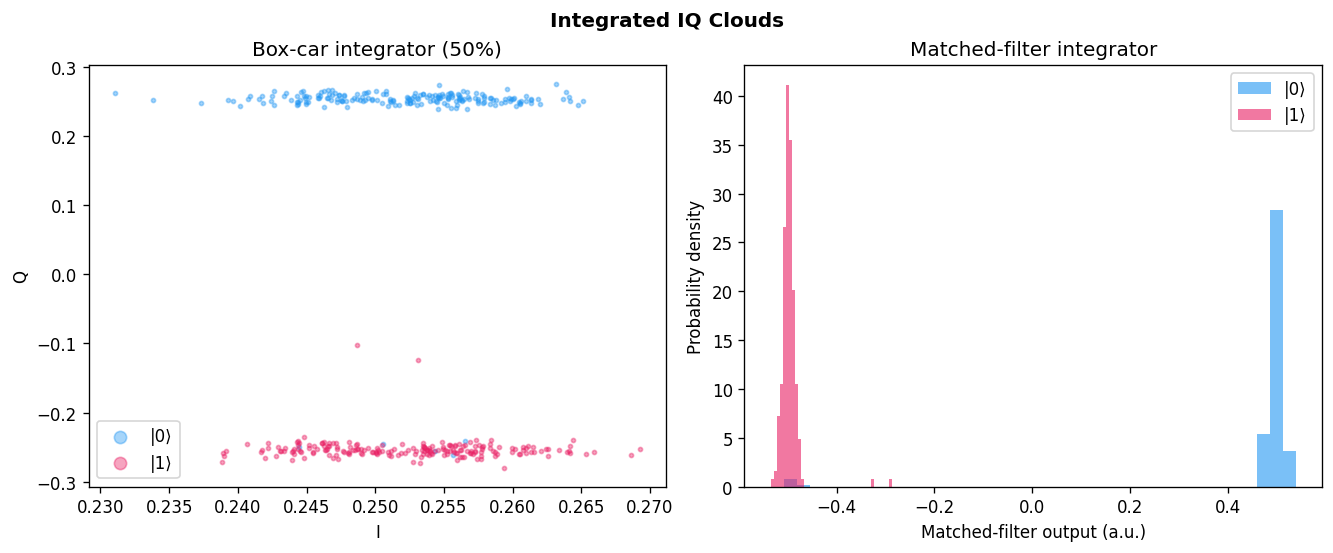

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
fig.suptitle("Integrated IQ Clouds", fontsize=12, fontweight="bold")

# Box-car
ax = axes[0]
ax.scatter(iq_bc_0.real, iq_bc_0.imag, s=6, alpha=0.4,
           color="#2196F3", label="|0⟩", rasterized=True)
ax.scatter(iq_bc_1.real, iq_bc_1.imag, s=6, alpha=0.4,
           color="#E91E63", label="|1⟩", rasterized=True)
ax.set_xlabel("I"); ax.set_ylabel("Q")
ax.set_title("Box-car integrator (50%)"); ax.legend(markerscale=3)

# Matched filter
ax = axes[1]
ax.hist(iq_mf_0, bins=40, alpha=0.6, color="#2196F3",
        label="|0⟩", density=True)
ax.hist(iq_mf_1, bins=40, alpha=0.6, color="#E91E63",
        label="|1⟩", density=True)
ax.set_xlabel("Matched-filter output (a.u.)")
ax.set_ylabel("Probability density")
ax.set_title("Matched-filter integrator"); ax.legend()
plt.show()